# <font color='blue'>Data Science Fábio Ferri - EDA Analisys and SAP SAC Storytelling </font>

# <font color='blue'>Downtime Machine Project </font>

# <font color='blue'> Downtime SAC Dashboard </font>

# <font color='blue'>23/2/2026</font>

In [1]:
# Import required libraries for dataframes and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import datetime

# Importing libraries for machine learning

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import joblib
from sklearn.ensemble import GradientBoostingClassifier


# Ignore warnings

import warnings
warnings.filterwarnings('ignore')

# Full display of columns and rows

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', 1000)

In [2]:
# Plot configuration parameters
from matplotlib import rcParams

rcParams['figure.figsize'] = 12, 4
rcParams['lines.linewidth'] = 3
rcParams['xtick.labelsize'] = 'x-large'
rcParams['ytick.labelsize'] = 'x-large'

import warnings
warnings.filterwarnings("ignore")

## Problem / Business Understanding

Identify and improve the Downtime and Machine Stop processes

## 2.2 Downtime (Stop Time)
This model focuses on identifying and monitoring machine stops to minimize production impact.

### Key Metrics:
•	Total Stop Time: Sum of all machine stop durations.

•	MTBF (Mean Time Between Failures): Average time a machine operates before failing.

•	MTTR (Mean Time To Repair): Average time required to repair a failure.

•	% Machine Availability: Percentage of time machines were operational.

•	Main Causes of Downtime: Identifies the most recurring causes of stops.



## Data Acquisition

Identify and obtain datasets relevant to the problem.
Collect data from multiple sources such as databases, APIs, local files, etc.

Data Definition



<img src="images/Columns_01.jpg"/>

Downtime and Scrap files

In [3]:
import os
for dirname, _, filenames in os.walk('dataset/RelatórioDOWNTIME_UPLOAD1.xlsx'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [4]:
df = pd.read_excel("dataset\RelatórioDOWNTIME_UPLOAD1.xlsx") 





In [5]:
df_fraction = df.sample(frac=0.2, random_state=42)
df_full = df
df = df_fraction


In [6]:
df.size

405790

In [7]:
df_full.size

2028950

## Data Cleaning and Preprocessing

In [8]:
## Function to scramble values while keeping frequency
def anonymize_column(df, column_name, prefix):
    unique_values = df[column_name].unique()
    # Generate unique fake labels
    fake_labels = [f"{prefix}_{i+1}" for i in range(len(unique_values))]
    np.random.shuffle(fake_labels)
    # Create mapping
    mapping = dict(zip(unique_values, fake_labels))
    # Apply mapping
    df[column_name] = df[column_name].map(mapping)
    return mapping

# Copy the original dataset
df_scrambled = df.copy()

# Apply anonymization to desired columns
cell_id_map = anonymize_column(df_scrambled, 'CELL_ID', 'CELL_ID')
part_number_map = anonymize_column(df_scrambled, 'PARM1', 'PART')
station_map = anonymize_column(df_scrambled, 'PARM8', 'STATION')
reporter_map = anonymize_column(df_scrambled, 'PARM2', 'REPORTER')


# Check that original values have been replaced
print("Unique values after scrambling:")
print("CELL_ID:", df_scrambled['CELL_ID'].unique()[:5])
print("Part_Number:", df_scrambled['PARM1'].unique()[:5])
print("Station:", df_scrambled['PARM8'].unique()[:5])

#copy to df
df = df_scrambled


Unique values after scrambling:
CELL_ID: ['CELL_ID_195' 'CELL_ID_129' 'CELL_ID_106' 'CELL_ID_83' 'CELL_ID_182']
Part_Number: ['PART_292' 'PART_36' 'PART_578' 'PART_230' 'PART_462']
Station: ['STATION_173' 'STATION_130' 'STATION_95' 'STATION_152' 'STATION_194']


In [9]:
df.columns

Index(['CELL_ID', 'PARM1', 'PARM2', 'PARM3', 'PARM4', 'PARM5', 'PARM6', 'PARM7', 'PARM8', 'PARM9', 'PARM10', 'PARM11', 'PARM12', 'PARM13', 'PARM14', 'PARM15', 'PARM16', 'FLAG', 'SENT', 'RESULT', 'TIME_STAMP', 'ID'], dtype='object')

In [10]:
df.describe()

,PARM3,PARM4,PARM7,PARM9,PARM10,PARM11,PARM12,PARM15,PARM16,SENT
count,18445.0,18445,18445.000000,18445.0,18445.000000,9344.000000,8247.000000,18371.000000,0.0,18445.000000
mean,111.0,2025-01-17 20:00:56.991054336,2.375007,10.0,6.532936,401.758990,2.494847,1070.352392,NaN,1.043589
min,111.0,2024-12-11 00:00:00,1.000000,10.0,4.000000,3.000000,0.000000,2.600000,NaN,0.000000
25%,111.0,2025-01-10 00:00:00,2.000000,10.0,4.000000,14.000000,1.000000,2.600000,NaN,1.000000
50%,111.0,2025-01-17 00:00:00,2.000000,10.0,9.000000,80.000000,2.000000,2110.000000,NaN,1.000000
75%,111.0,2025-01-24 00:00:00,3.000000,10.0,9.000000,113.000000,3.000000,2110.000000,NaN,1.000000
max,111.0,2025-02-01 00:00:00,3.000000,10.0,9.000000,9958.000000,10.000000,2110.000000,NaN,12.000000
std,0.0,NaN,0.569459,0.0,2.499851,1646.877627,1.794754,1053.634970,NaN,0.695781


In [11]:
# Checking for missing values
print(df.isna().sum())


CELL_ID           0
PARM1             0
PARM2             0
PARM3             0
PARM4             0
PARM5             0
PARM6             0
PARM7             0
PARM8             0
PARM9             0
PARM10            0
PARM11         9101
PARM12        10198
PARM13         3892
PARM14        18365
PARM15           74
PARM16        18445
FLAG              0
SENT              0
RESULT           74
TIME_STAMP        0
ID                0
dtype: int64


In [12]:
# Checking unique values
df.nunique()

CELL_ID         198
PARM1           609
PARM2           767
PARM3             1
PARM4            32
PARM5          9665
PARM6          9899
PARM7             3
PARM8           198
PARM9             1
PARM10            2
PARM11          164
PARM12           11
PARM13          133
PARM14            1
PARM15            2
PARM16            0
FLAG              2
SENT              3
RESULT         9064
TIME_STAMP    18445
ID            18445
dtype: int64

In [13]:
# Checking for missing values
print(df.isna().sum())

CELL_ID           0
PARM1             0
PARM2             0
PARM3             0
PARM4             0
PARM5             0
PARM6             0
PARM7             0
PARM8             0
PARM9             0
PARM10            0
PARM11         9101
PARM12        10198
PARM13         3892
PARM14        18365
PARM15           74
PARM16        18445
FLAG              0
SENT              0
RESULT           74
TIME_STAMP        0
ID                0
dtype: int64


In [14]:
# Remove records with NA values and drop the two first columns (not necessary)
#df_downtime = df.dropna()
# Remove columns without significant data
df_downtime = df.drop(columns=['PARM14', 'PARM16'])



In [15]:
# Checking for missing values
print(df_downtime.isna().sum())

CELL_ID           0
PARM1             0
PARM2             0
PARM3             0
PARM4             0
PARM5             0
PARM6             0
PARM7             0
PARM8             0
PARM9             0
PARM10            0
PARM11         9101
PARM12        10198
PARM13         3892
PARM15           74
FLAG              0
SENT              0
RESULT           74
TIME_STAMP        0
ID                0
dtype: int64


In [16]:
df_downtime.shape

(18445, 20)

## Data Cleaning and Preprocessing

Assess data quality and handle issues such as missing values, outliers and errors.
Normalize or standardize data if necessary.

Data Treatment Rules
* If the field Result is OK then PARAM12 must be 0
* If columns PARAM12 and PARAM13 are NULL then replace with 0
* Extract the TimeStamp column to derive temporal measures: Day/Month/Year, Week Number, Weekday
* RESULT if OK = 1 (no Downtime) else 0 indicates Downtime


In [17]:
# List of columns to fix
columns_to_fix = ['PARM11','PARM12', 'PARM13']

# Loop to replace null or blank values with 0
for col in columns_to_fix:
    df_downtime[col] = df_downtime[col].replace(['', None, np.nan], 0)


# Converting TIME_STAMP to datetime
df_downtime['TIME_STAMP'] = pd.to_datetime(df_downtime['TIME_STAMP']) 

# Creating new columns
df_downtime['Date_D']  = df_downtime['TIME_STAMP'].dt.date       # Date only
df_downtime['Time_D']  = df_downtime['TIME_STAMP'].dt.strftime('%H:%M:%S')  # Format HH:MM:SS
df_downtime['WeekDay'] = df_downtime['TIME_STAMP'].dt.day_name()  # Weekday name
df_downtime['Month_D'] = df_downtime['TIME_STAMP'].dt.month_name()  # Month name


#df_downtime['RESULT_D'] = df['RESULT'].apply(lambda x: 1 if x == 'OK' else 0)
df_downtime['RESULT_D'] = df['PARM10'].apply(lambda x: 1 if x == 9 else  0)




# Function to format hour values
def formatar_hora(valor):
    if isinstance(valor, datetime.time):
        return valor.strftime('%H:%M')
    else:
        valor = int(valor)
        horas = valor // 100
        minutos = valor % 100
        return f'{horas:02d}:{minutos:02d}'

# Apply the function
df_downtime['PARM5'] = df_downtime['PARM5'].apply(formatar_hora)
df_downtime['PARM6'] = df_downtime['PARM6'].apply(formatar_hora)

# Convert columns to datetime (hour and minute)
#df_downtime['PARM5'] = pd.to_datetime(df_downtime['PARM5'], format='%H:%M')
#df_downtime['PARM6'] = pd.to_datetime(df_downtime['PARM6'], format='%H:%M')


In [18]:
df_downtime.size

461125

In [19]:
df_downtime.head(5)

,CELL_ID,PARM1,PARM2,PARM3,PARM4,PARM5,PARM6,PARM7,PARM8,PARM9,PARM10,PARM11,PARM12,PARM13,PARM15,FLAG,SENT,RESULT,TIME_STAMP,ID,Date_D,Time_D,WeekDay,Month_D,RESULT_D
24370,CELL_ID_195,PART_292,REPORTER_10,111,2025-01-10,22:54,23:02,3,STATION_173,10,9,10.0,0.0,0,2110.0,REP,1,OK,2025-01-10 23:32:37.650,97D6D7B9-3ED2-49F4-B0D4-87B5834304D2,2025-01-10,23:32:37,Friday,January,1
47615,CELL_ID_129,PART_36,REPORTER_511,111,2025-01-19,13:32,13:38,2,STATION_130,10,9,14.0,0.0,250192,2110.0,REP,1,OK,2025-01-19 14:32:22.770,D9840CC0-A909-4B04-97F3-5ED65210CE52,2025-01-19,14:32:22,Sunday,January,1
78557,CELL_ID_106,PART_578,REPORTER_405,111,2025-01-28,20:31,20:35,3,STATION_95,10,9,122.0,0.0,202575,2110.0,REP,1,OK,2025-01-28 21:32:54.643,FE102354-38A3-4140-AAB5-D7D5F3AEC699,2025-01-28,21:32:54,Tuesday,January,1
41635,CELL_ID_83,PART_230,REPORTER_133,111,2025-01-16,18:01,18:36,3,STATION_152,10,4,0.0,2.0,250163,2.6,REP,1,||runLabor#1(emp-1000367) item#1(part-40117524...,2025-01-16 19:06:44.560,DB8B4DD3-7E6D-4A92-A3C7-29ED51AA283B,2025-01-16,19:06:44,Thursday,January,0
68627,CELL_ID_182,PART_462,REPORTER_365,111,2025-01-24,14:48,17:40,3,STATION_194,10,4,0.0,1.0,250243,2.6,REP,1,||runLabor#1(emp-1001540) item#1(part-40128540...,2025-01-24 18:06:45.070,B1FED063-D65A-4835-BCDA-7C48D26DFFA9,2025-01-24,18:06:45,Friday,January,0


In [20]:
# Rename columns
df_downtime.rename(columns={'PARM1': 'Part_Number', 
                   'PARM2': 'Reported_Pointed',
                   'PARM3' : 'Local', 
                   'PARM4' : 'Date',
                   'PARM5' : 'Start_Time_Appoint',
                   'PARM6' : 'End_TimeAppoint', 
                   'PARM7' : 'Shift',
                   'PARM8' : 'Station',
                   'PARM9' : 'ReasonforStop',
                   'PARM10' : 'stop/prodution',
                   'PARM11' : 'Reason_Code'
                     }, inplace=True)

In [21]:
df_downtime = df_downtime.reset_index(drop=True)

## Exploratory Data Analysis

Data Exploration:
Perform exploratory analyses to understand data distribution, identify patterns and relationships.
Visualize data using charts and descriptive statistics.

### Separation of Categorical and Numerical Variables

In [22]:
# Get sample
#df_downtime = df_downtime.sample(frac=0.1, replace=True, random_state=1)

# Show shape
print(df_downtime.shape)

# Separate numeric columns
df_numerico = df_downtime.select_dtypes(include=['number'])

# Separate object columns (strings, categories, etc.)
df_objetos = df_downtime.select_dtypes(include=['object'])

# Display separated DataFrames
#print("Numeric DataFrame:")
#print(df_numerico)

#print("\nObject DataFrame:")
#print(df_objetos)

(18445, 25)


In [23]:
# List of categorical columns
cats = df_objetos.columns.tolist()

In [24]:
# List of numeric columns
nums = df_numerico.columns.tolist()

In [25]:
# Summary of categorical variables
df_downtime[cats].describe()

,CELL_ID,Part_Number,Reported_Pointed,Start_Time_Appoint,End_TimeAppoint,Station,PARM13,FLAG,RESULT,ID,Date_D,Time_D,WeekDay,Month_D
count,18445,18445,18445,18445,18445,18445,18445,18445,18371,18445,18445,18445,18445,18445
unique,198,609,767,1385,1394,198,134,2,9064,18445,31,7272,7,2
top,CELL_ID_12,PART_75,REPORTER_610,14:48,14:00,STATION_166,0,REP,OK,F4809B4F-AA9A-4E7C-AFB4-D5A973BB6D7C,2025-01-23,08:33:13,Thursday,January
freq,526,475,178,124,127,526,3892,18371,9307,1,931,11,3894,18350


In [26]:
# List of numeric features
nums

['Local',
 'Shift',
 'ReasonforStop',
 'stop/prodution',
 'Reason_Code',
 'PARM12',
 'PARM15',
 'SENT',
 'RESULT_D']

In [27]:
# List of categorical features
cats

['CELL_ID',
 'Part_Number',
 'Reported_Pointed',
 'Start_Time_Appoint',
 'End_TimeAppoint',
 'Station',
 'PARM13',
 'FLAG',
 'RESULT',
 'ID',
 'Date_D',
 'Time_D',
 'WeekDay',
 'Month_D']

In [28]:
# Print counts per category for each categorical variable
#for col in cats:
#    print(f'''Total Records Per Category for Variable {col}:''')
#    print(df_downtime[col].value_counts())
#    print()

### Categorical Variables

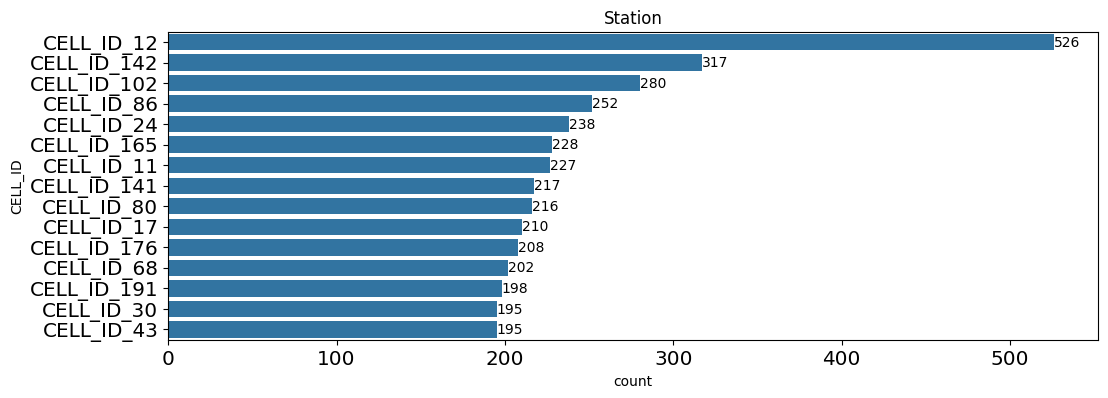

In [29]:
n = 15

message = "Top "   +  str(n) + " Station"
order = pd.value_counts(df_downtime['CELL_ID']).iloc[:n].index
ax = sns.countplot(y='CELL_ID', data=df_downtime, order=order)
# Add chart title
ax.set(title="Station")
# Add count labels to each bar
ax.bar_label(ax.containers[0])
# Show the plot
plt.show()




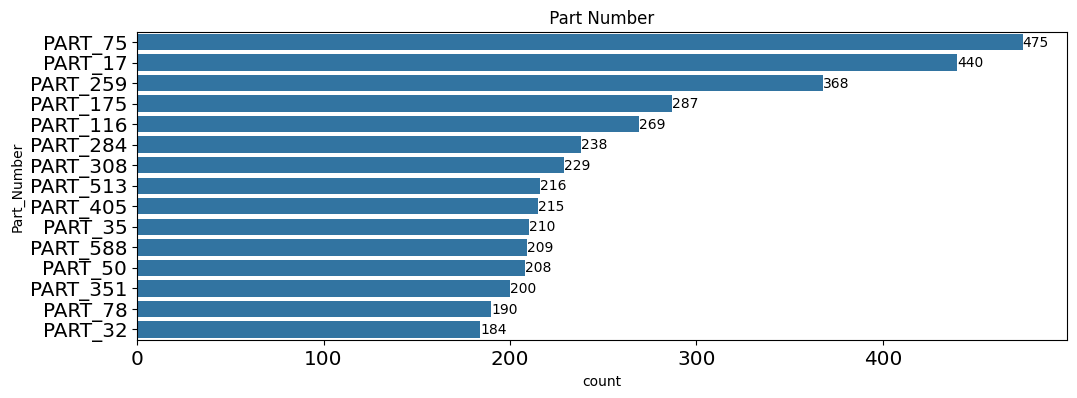

In [30]:
# Count plot for the target variable
#sns.countplot(data = df_downtime, x = df_downtime['Part_Number'], hue = 'Part_Number')

n = 15

message = "Top "   +  str(n) + " Part Number"
order = pd.value_counts(df_downtime['Part_Number']).iloc[:n].index
ax = sns.countplot(y='Part_Number', data=df_downtime, order=order)
# Add chart title
ax.set(title=" Part Number ")
# Add count labels to each bar
ax.bar_label(ax.containers[0])
# Show the plot
plt.show()

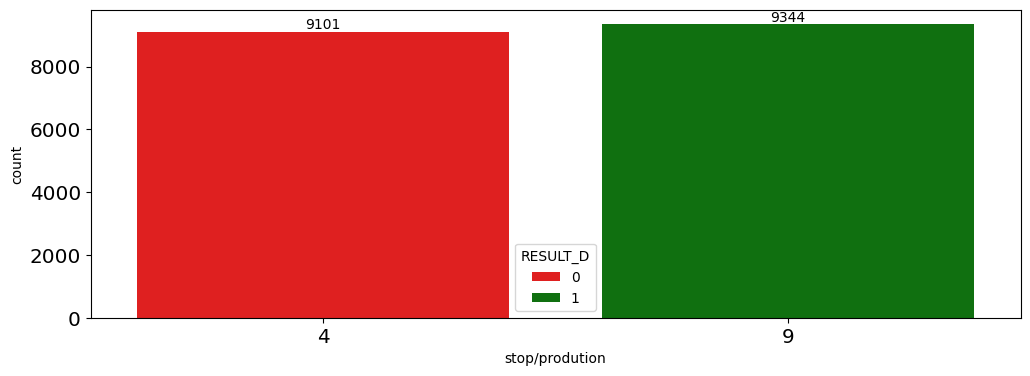

In [31]:

# 9 = Production Running: Status 9 may indicate a downtime event ended and production resumed.
# 4 = Machine Fault/Error: Status 4 may indicate downtime due to a specific machine error code.

# Define a custom color palette
custom_palette = {0: 'red', 1: 'green'}
#
# Create the plot and store the Axes object
ax = sns.countplot(data=df_downtime, x='stop/prodution', hue='RESULT_D', palette=custom_palette)

# Iterate over containers and add count labels
for container in ax.containers:
    ax.bar_label(container)

# Show the plot
plt.show()

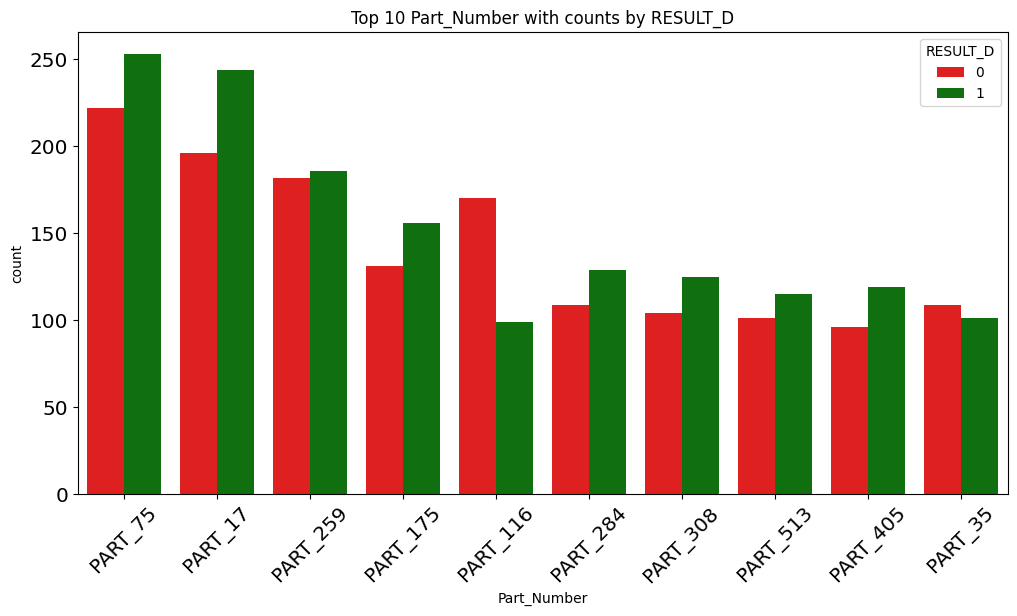

In [32]:
# Count plot for the target variable (Top 10 Part_Number)

# Define custom palette

custom_palette = {0: 'red', 1: 'green'}


top_10_parm1 = df_downtime['Part_Number'].value_counts().nlargest(10).index
df_top10 = df_downtime[df_downtime['Part_Number'].isin(top_10_parm1)]

# Create the plot with top 10
plt.figure(figsize=(12, 6))
sns.countplot(data=df_top10, x='Part_Number', hue='RESULT_D', order=top_10_parm1, palette=custom_palette)
plt.xticks(rotation=45)
plt.title('Top 10 Part_Number with counts by RESULT_D')
plt.show()

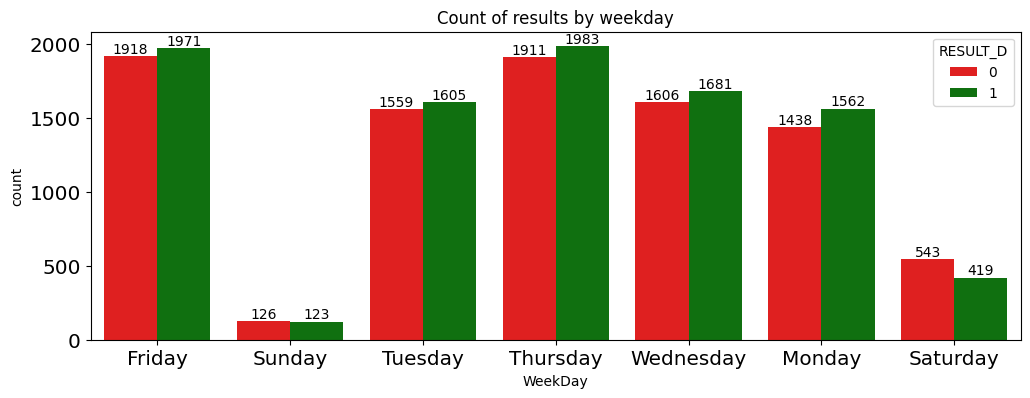

In [33]:
# Count plot for weekday by RESULT_D

# Define custom palette
custom_palette = {0: 'red', 1: 'green'}

# Create the plot and store the Axes object
ax = sns.countplot(data=df_downtime, x='WeekDay', hue='RESULT_D', palette=custom_palette)

# Iterate over containers and add count labels
for container in ax.containers:
    ax.bar_label(container)

# Add an optional title
ax.set_title('Count of results by weekday')

# Show the plot
plt.show()

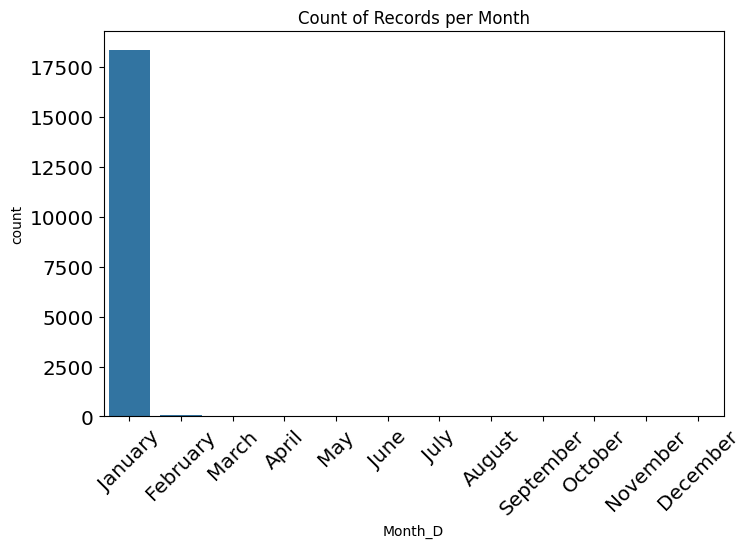

In [34]:
# Step 2: Make a countplot
plt.figure(figsize=(8,5))
sns.countplot(data=df_downtime, x='Month_D', order=[
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
])
plt.xticks(rotation=45)
plt.title('Count of Records per Month')


# Show the plot
plt.show()

### Numerical Variables

In [35]:
# List of numeric variables
nums

['Local',
 'Shift',
 'ReasonforStop',
 'stop/prodution',
 'Reason_Code',
 'PARM12',
 'PARM15',
 'SENT',
 'RESULT_D']

['Local', 'Shift', 'ReasonforStop', 'stop/prodution', 'Reason_Code', 'PARM12', 'PARM15', 'SENT', 'RESULT_D']


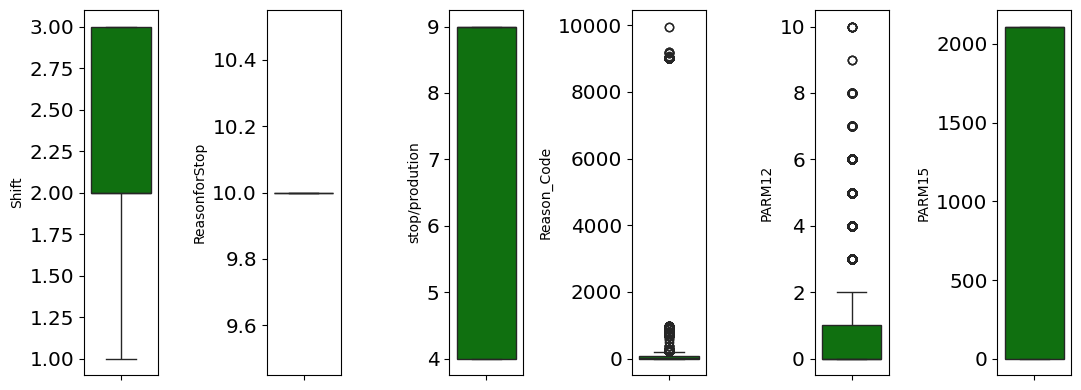

In [36]:
features = nums
print(nums)
for i in range(1, 7):
    plt.subplot(1, 7, i + 1)
    sns.boxplot(y = df_downtime[features[i]], color = 'green', orient = 'v' )
    plt.tight_layout()

# Parameter analysis:
* PARM3 = constant 111
* PARM7 = SHIFT ?
* PARM9 = constant 10
* PARM10 = Values between 4 and 9 (stop/production status)

In [37]:
atures = nums
for i in range(8, 8):
    plt.subplot(2, 8, i + 1)
    sns.boxplot(y = df_downtime[features[i]], color = 'green', orient = 'v' )
    plt.tight_layout()

### Parameter analysis:
PARM11 and PARM12 have outlier values far from the mean

In [38]:
cats_1 = cats[:6]
cats_2 = cats[6:]

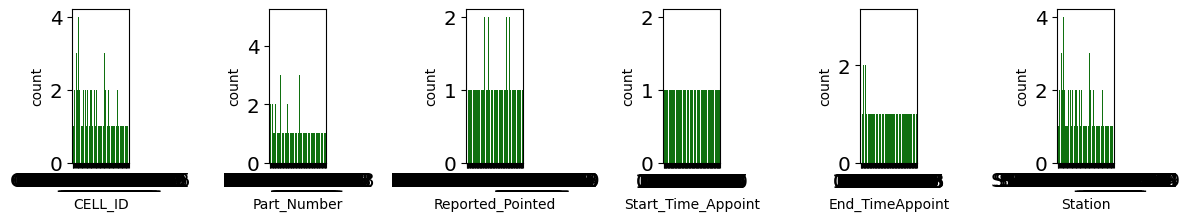

In [39]:
df_sample = df_downtime.sample(100, random_state = 42)
for i in range(0, len(cats_1)):
    plt.subplot(2, 6, i+1)
    sns.countplot(x = df_sample[cats[i]], color = 'green', orient = 'v')
    plt.tight_layout()

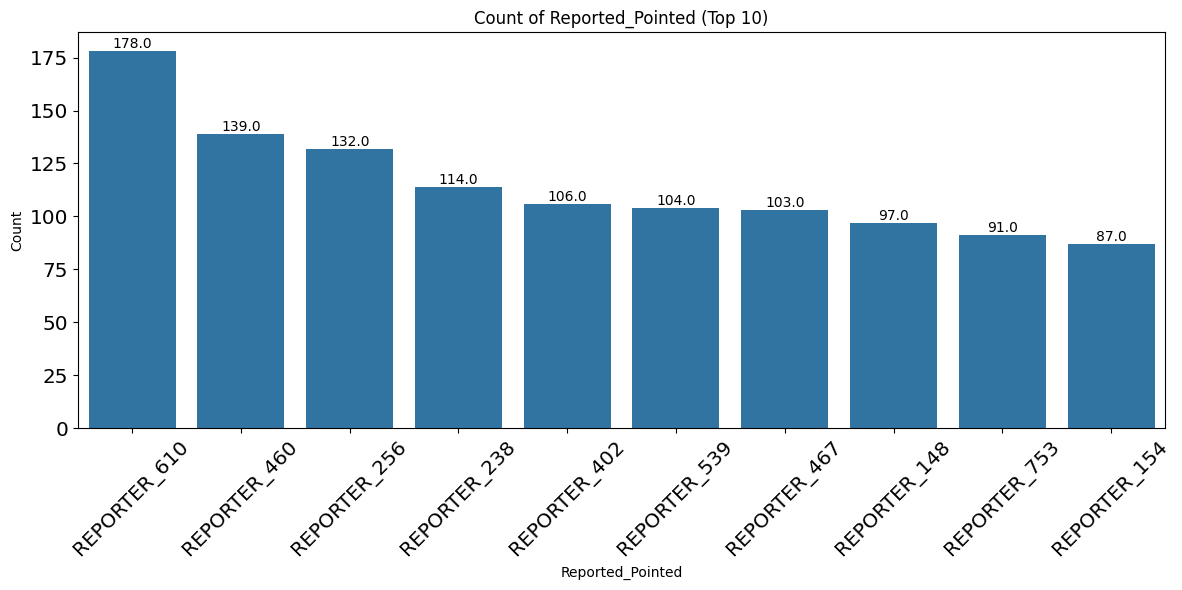

In [40]:
# Select the 10 most frequent values of 'Reported_Pointed'
top_10_Reported_Pointed = df_downtime['Reported_Pointed'].value_counts().nlargest(10).index

# Filter the DataFrame to only contain the top 10
df_top10 = df_downtime[df_downtime['Reported_Pointed'].isin(top_10_Reported_Pointed)]

# Create bar chart with counts
plt.figure(figsize=(12, 6))
ax = sns.countplot(data=df_top10, x='Reported_Pointed', order=top_10_Reported_Pointed)

# Add values on top of bars
for p in ax.patches:
    ax.annotate(
        f'{p.get_height()}',                # value
        (p.get_x() + p.get_width() / 2.,   # x center position
         p.get_height()),                   # y position at bar top
        ha='center', va='bottom', fontsize=10, color='black'
    )

plt.xticks(rotation=45)
plt.title('Count of Reported_Pointed (Top 10)')
plt.ylabel('Count')
plt.xlabel('Reported_Pointed')
plt.tight_layout()
plt.show()

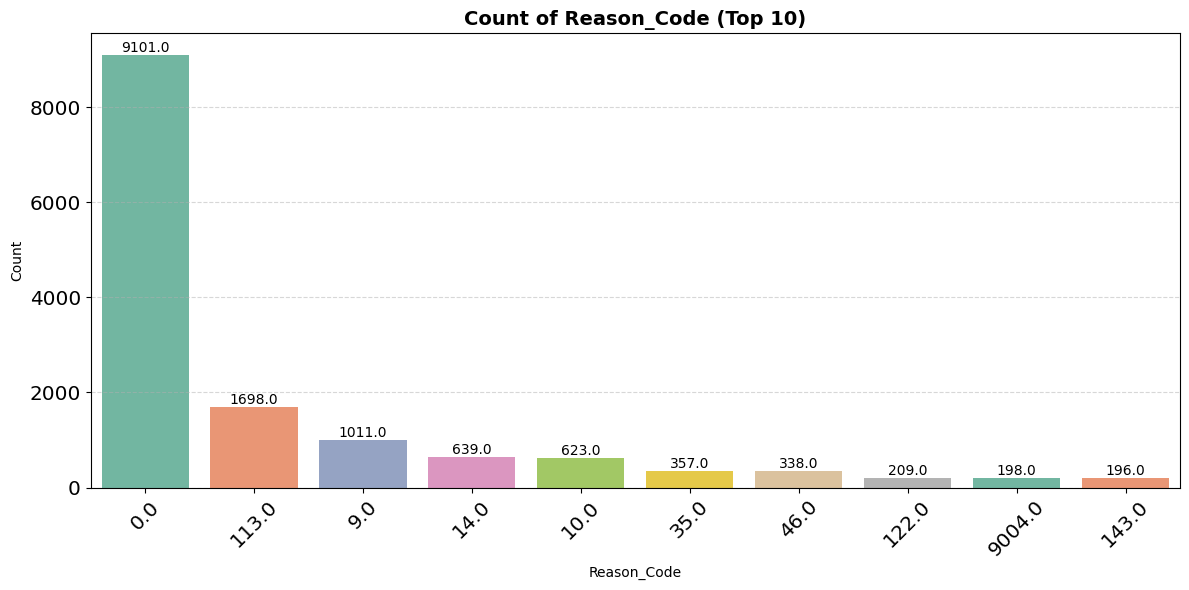

In [41]:
# Select the 10 most frequent values of 'Reason_Code'
top_10_Reason_Code = df_downtime['Reason_Code'].value_counts().nlargest(10).index

# Filter the DataFrame to only contain the top 10
df_top10_Reason_Code = df_downtime[df_downtime['Reason_Code'].isin(top_10_Reason_Code)]

# Create bar chart with counts and a custom palette
plt.figure(figsize=(12, 6))
ax = sns.countplot(
    data=df_top10_Reason_Code,
    x='Reason_Code',
    order=top_10_Reason_Code,
    palette='Set2'  # or use ['#color1', '#color2', ...] for specific colors
)

# Add values on top of bars
for p in ax.patches:
    ax.annotate(
        f'{p.get_height()}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom', fontsize=10, color='black'
    )

plt.xticks(rotation=45)
plt.title('Count of Reason_Code (Top 10)', fontsize=14, weight='bold')
plt.ylabel('Count')
plt.xlabel('Reason_Code')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


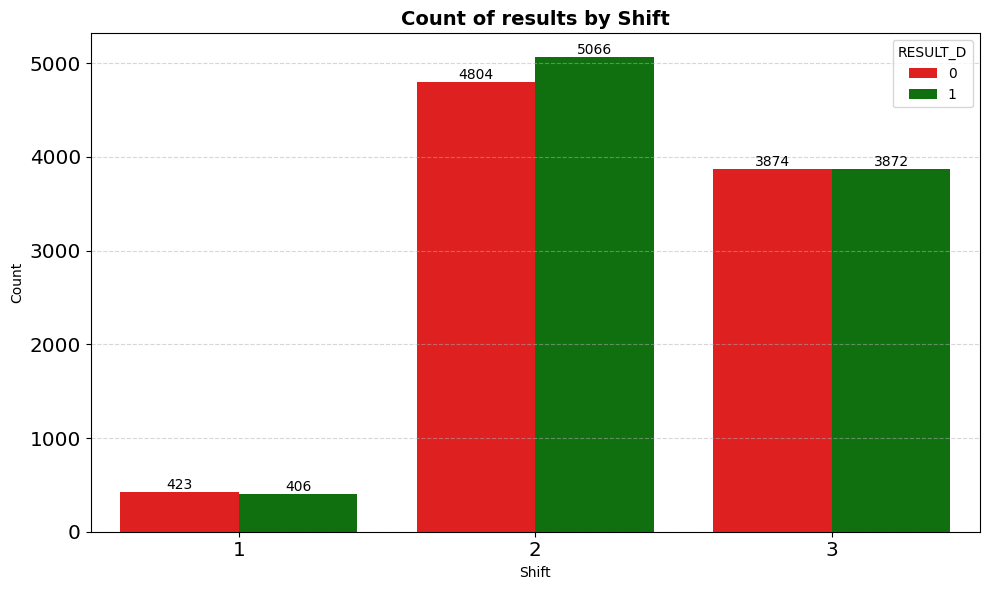

In [42]:

# Define a custom color palette
custom_palette = {0: 'red', 1: 'green'}

# Create the plot with colors based on RESULT_D
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df_downtime, x='Shift', hue='RESULT_D', palette=custom_palette)

# Add count labels to each bar
for container in ax.containers:
    ax.bar_label(container, fontsize=10)

# Title and visual adjustments
ax.set_title('Count of results by Shift', fontsize=14, weight='bold')
plt.xlabel('Shift')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


### Bivariate Analysis - Correlation Map

In [43]:
#df[nums].corr()

## Data Preprocessing

In [44]:

def remover_outliers(df):
    # For each numeric column in the DataFrame
    for coluna in df.select_dtypes(include=['number']).columns:
        # Compute the mean of the column
        media = df[coluna].mean()
        
        # Compute upper and lower limits (30% above and below the mean)
        limite_superior = media * 1.30
        limite_inferior = media * 0.70
        
        # Filter data within the limits
        df = df[(df[coluna] >= limite_inferior) & (df[coluna] <= limite_superior)]
    
    return df

# Apply the function to your DataFrame
#df_downtime = remover_outliers(df_downtime)

In [45]:
# start time and end time
def subtract_times_minutes(date_apt,start_time, end_time): 
    #date_apt = pd.to_datetime(date_apt, format='%Y-%m-%d')
    start_time = datetime.strptime(date_apt,start_time, "%H:%M")
    end_time = datetime.strptime(date_apt, end_time, "%H:%M")

    # get difference
    delta = end_time - start_time

    sec = delta.total_seconds()
    #print('difference in seconds:', sec)

    min = sec / 60
    #print('difference in minutes:', min)

    # get difference in hours
    #hours = sec / (60 * 60)
    #print('difference in hours:', hours)
    return min

2.2 Downtime (Stop Time)
This model focuses on identifying and monitoring machine stops to minimize production impact.

Key Indicators:
Total Stop Time: Sum of all machine stop durations.

MTBF (Mean Time Between Failures): Global average time a machine operates before failing.

MTTR (Mean Time To Repair): Global average time required to repair a failure.

% Machine Availability: Percentage of time machines were operational.

Main Causes of Downtime: Identifies the most recurring causes of stops.

In [46]:

df_downtime.head(10)

,CELL_ID,Part_Number,Reported_Pointed,Local,Date,Start_Time_Appoint,End_TimeAppoint,Shift,Station,ReasonforStop,stop/prodution,Reason_Code,PARM12,PARM13,PARM15,FLAG,SENT,RESULT,TIME_STAMP,ID,Date_D,Time_D,WeekDay,Month_D,RESULT_D
0,CELL_ID_195,PART_292,REPORTER_10,111,2025-01-10,22:54,23:02,3,STATION_173,10,9,10.0,0.0,0,2110.0,REP,1,OK,2025-01-10 23:32:37.650,97D6D7B9-3ED2-49F4-B0D4-87B5834304D2,2025-01-10,23:32:37,Friday,January,1
1,CELL_ID_129,PART_36,REPORTER_511,111,2025-01-19,13:32,13:38,2,STATION_130,10,9,14.0,0.0,250192,2110.0,REP,1,OK,2025-01-19 14:32:22.770,D9840CC0-A909-4B04-97F3-5ED65210CE52,2025-01-19,14:32:22,Sunday,January,1
2,CELL_ID_106,PART_578,REPORTER_405,111,2025-01-28,20:31,20:35,3,STATION_95,10,9,122.0,0.0,202575,2110.0,REP,1,OK,2025-01-28 21:32:54.643,FE102354-38A3-4140-AAB5-D7D5F3AEC699,2025-01-28,21:32:54,Tuesday,January,1
3,CELL_ID_83,PART_230,REPORTER_133,111,2025-01-16,18:01,18:36,3,STATION_152,10,4,0.0,2.0,250163,2.6,REP,1,||runLabor#1(emp-1000367) item#1(part-40117524...,2025-01-16 19:06:44.560,DB8B4DD3-7E6D-4A92-A3C7-29ED51AA283B,2025-01-16,19:06:44,Thursday,January,0
4,CELL_ID_182,PART_462,REPORTER_365,111,2025-01-24,14:48,17:40,3,STATION_194,10,4,0.0,1.0,250243,2.6,REP,1,||runLabor#1(emp-1001540) item#1(part-40128540...,2025-01-24 18:06:45.070,B1FED063-D65A-4835-BCDA-7C48D26DFFA9,2025-01-24,18:06:45,Friday,January,0
5,CELL_ID_131,PART_471,REPORTER_427,111,2025-01-15,15:16,15:30,3,STATION_168,10,9,143.0,0.0,250153,2110.0,REP,1,OK,2025-01-15 16:32:10.440,3272BE01-DE6C-45E3-A0A8-77D974456565,2025-01-15,16:32:10,Wednesday,January,1
6,CELL_ID_92,PART_68,REPORTER_267,111,2025-01-29,08:02,10:46,2,STATION_141,10,4,0.0,1.0,250292,2.6,REP,1,||runLabor#1(emp-1001906) item#1(part-40128520...,2025-01-29 11:07:07.260,D8856AB3-1ADA-475E-85EC-CF2330E2BF59,2025-01-29,11:07:07,Wednesday,January,0
7,CELL_ID_186,PART_38,REPORTER_445,111,2025-01-15,01:02,02:50,1,STATION_64,10,4,0.0,2.0,250151,2.6,REP,1,||runLabor#1(emp-6815) item#1(part-4012481)|| ...,2025-01-15 03:04:28.410,B766BD71-1147-465B-B58B-7C8B72EE2231,2025-01-15,03:04:28,Wednesday,January,0
8,CELL_ID_1,PART_236,REPORTER_716,111,2025-01-24,16:34,17:06,3,STATION_163,10,4,0.0,2.0,250243,2.6,REP,1,||runLabor#1(emp-1000956) item#1(part-4010552F...,2025-01-24 18:05:26.053,E6573BBB-D9D9-40E6-8CC5-C55032B10AC3,2025-01-24,18:05:26,Friday,January,0
9,CELL_ID_29,PART_116,REPORTER_721,111,2025-01-08,14:26,14:28,2,STATION_119,10,9,107.0,0.0,0,2110.0,REP,1,OK,2025-01-08 15:32:14.173,29AE85D3-4DA7-472C-B103-6ACD490D29F5,2025-01-08,15:32:14,Wednesday,January,1


In [47]:
# Assign new fields

## Total Stop Time: Sum of all machine stop durations.

df_downtime['Start_Time_Appoint'] = pd.to_datetime(df_downtime['Start_Time_Appoint'], format='%H:%M')
df_downtime['End_TimeAppoint'] = pd.to_datetime(df_downtime['End_TimeAppoint'], format='%H:%M')


# Filter only rows where stop/prodution == 4 (stopped)
df_stoped = df_downtime[df_downtime['stop/prodution'] == 4].copy()

df_stoped = df_stoped.reset_index()

df_stoped['Tot_DownTime'] = abs((df_stoped['End_TimeAppoint'] - df_stoped['Start_Time_Appoint']))

print(df_stoped.size,"df_stoped")


# Filter only rows where stop/prodution == 9 (OK / running)
df_run_ok = df_downtime[df_downtime['stop/prodution'] == 9].copy()

df_run_ok = df_run_ok.reset_index()

# Convert 'a' and 'b' to time format if needed
#df_run_ok['Start_Time_Appoint'] = pd.to_datetime(df_run_ok['Start_Time_Appoint'], format='%H:%M:%S')
#df_run_ok['End_TimeAppoint'] = pd.to_datetime(df_run_ok['End_TimeAppoint'], format='%H:%M:%S')


# Calculate the difference in seconds for OK (running)

df_run_ok['Tot_Run_OK'] = abs(df_run_ok['End_TimeAppoint'] - df_run_ok['Start_Time_Appoint'])

print(df_run_ok.size,"df_run_ok")

df_final = df_downtime.merge(df_stoped[['ID', 'Tot_DownTime']], on='ID', how='left')

df_final = df_final.merge(df_run_ok[['ID', 'Tot_Run_OK']], on='ID', how='left')

df_final['Tot_DownTime'] = df_final['Tot_DownTime'].fillna(0)

df_final['Tot_Run_OK'] = df_final['Tot_Run_OK'].fillna(0)



df_final['DifApointMinutes'] = df_final.apply(
    lambda row: abs((row['End_TimeAppoint'] - row['Start_Time_Appoint']).total_seconds()) / 60,
    axis=1
)

df_final['DifApointMinutes'] = df_final['DifApointMinutes'].apply(lambda x: x * -1 if x < 0 else x)



df_run_eda = df_final[df_final['RESULT_D'] == 1].copy()
df_run_eda = df_run_eda.reset_index()


df_downtime_eda = df_final[df_final['RESULT_D'] == 0].copy()
df_downtime_eda = df_downtime_eda.reset_index()





#print(df_final.size,"df_downtime")




245727 df_stoped
252288 df_run_ok


In [48]:
df_final.head(30)

,CELL_ID,Part_Number,Reported_Pointed,Local,Date,Start_Time_Appoint,End_TimeAppoint,Shift,Station,ReasonforStop,stop/prodution,Reason_Code,PARM12,PARM13,PARM15,FLAG,SENT,RESULT,TIME_STAMP,ID,Date_D,Time_D,WeekDay,Month_D,RESULT_D,Tot_DownTime,Tot_Run_OK,DifApointMinutes
0,CELL_ID_195,PART_292,REPORTER_10,111,2025-01-10,1900-01-01 22:54:00,1900-01-01 23:02:00,3,STATION_173,10,9,10.0,0.0,0,2110.0,REP,1,OK,2025-01-10 23:32:37.650,97D6D7B9-3ED2-49F4-B0D4-87B5834304D2,2025-01-10,23:32:37,Friday,January,1,0,0 days 00:08:00,8.0
1,CELL_ID_129,PART_36,REPORTER_511,111,2025-01-19,1900-01-01 13:32:00,1900-01-01 13:38:00,2,STATION_130,10,9,14.0,0.0,250192,2110.0,REP,1,OK,2025-01-19 14:32:22.770,D9840CC0-A909-4B04-97F3-5ED65210CE52,2025-01-19,14:32:22,Sunday,January,1,0,0 days 00:06:00,6.0
2,CELL_ID_106,PART_578,REPORTER_405,111,2025-01-28,1900-01-01 20:31:00,1900-01-01 20:35:00,3,STATION_95,10,9,122.0,0.0,202575,2110.0,REP,1,OK,2025-01-28 21:32:54.643,FE102354-38A3-4140-AAB5-D7D5F3AEC699,2025-01-28,21:32:54,Tuesday,January,1,0,0 days 00:04:00,4.0
3,CELL_ID_83,PART_230,REPORTER_133,111,2025-01-16,1900-01-01 18:01:00,1900-01-01 18:36:00,3,STATION_152,10,4,0.0,2.0,250163,2.6,REP,1,||runLabor#1(emp-1000367) item#1(part-40117524...,2025-01-16 19:06:44.560,DB8B4DD3-7E6D-4A92-A3C7-29ED51AA283B,2025-01-16,19:06:44,Thursday,January,0,0 days 00:35:00,0,35.0
4,CELL_ID_182,PART_462,REPORTER_365,111,2025-01-24,1900-01-01 14:48:00,1900-01-01 17:40:00,3,STATION_194,10,4,0.0,1.0,250243,2.6,REP,1,||runLabor#1(emp-1001540) item#1(part-40128540...,2025-01-24 18:06:45.070,B1FED063-D65A-4835-BCDA-7C48D26DFFA9,2025-01-24,18:06:45,Friday,January,0,0 days 02:52:00,0,172.0
5,CELL_ID_131,PART_471,REPORTER_427,111,2025-01-15,1900-01-01 15:16:00,1900-01-01 15:30:00,3,STATION_168,10,9,143.0,0.0,250153,2110.0,REP,1,OK,2025-01-15 16:32:10.440,3272BE01-DE6C-45E3-A0A8-77D974456565,2025-01-15,16:32:10,Wednesday,January,1,0,0 days 00:14:00,14.0
6,CELL_ID_92,PART_68,REPORTER_267,111,2025-01-29,1900-01-01 08:02:00,1900-01-01 10:46:00,2,STATION_141,10,4,0.0,1.0,250292,2.6,REP,1,||runLabor#1(emp-1001906) item#1(part-40128520...,2025-01-29 11:07:07.260,D8856AB3-1ADA-475E-85EC-CF2330E2BF59,2025-01-29,11:07:07,Wednesday,January,0,0 days 02:44:00,0,164.0
7,CELL_ID_186,PART_38,REPORTER_445,111,2025-01-15,1900-01-01 01:02:00,1900-01-01 02:50:00,1,STATION_64,10,4,0.0,2.0,250151,2.6,REP,1,||runLabor#1(emp-6815) item#1(part-4012481)|| ...,2025-01-15 03:04:28.410,B766BD71-1147-465B-B58B-7C8B72EE2231,2025-01-15,03:04:28,Wednesday,January,0,0 days 01:48:00,0,108.0
8,CELL_ID_1,PART_236,REPORTER_716,111,2025-01-24,1900-01-01 16:34:00,1900-01-01 17:06:00,3,STATION_163,10,4,0.0,2.0,250243,2.6,REP,1,||runLabor#1(emp-1000956) item#1(part-4010552F...,2025-01-24 18:05:26.053,E6573BBB-D9D9-40E6-8CC5-C55032B10AC3,2025-01-24,18:05:26,Friday,January,0,0 days 00:32:00,0,32.0
9,CELL_ID_29,PART_116,REPORTER_721,111,2025-01-08,1900-01-01 14:26:00,1900-01-01 14:28:00,2,STATION_119,10,9,107.0,0.0,0,2110.0,REP,1,OK,2025-01-08 15:32:14.173,29AE85D3-4DA7-472C-B103-6ACD490D29F5,2025-01-08,15:32:14,Wednesday,January,1,0,0 days 00:02:00,2.0


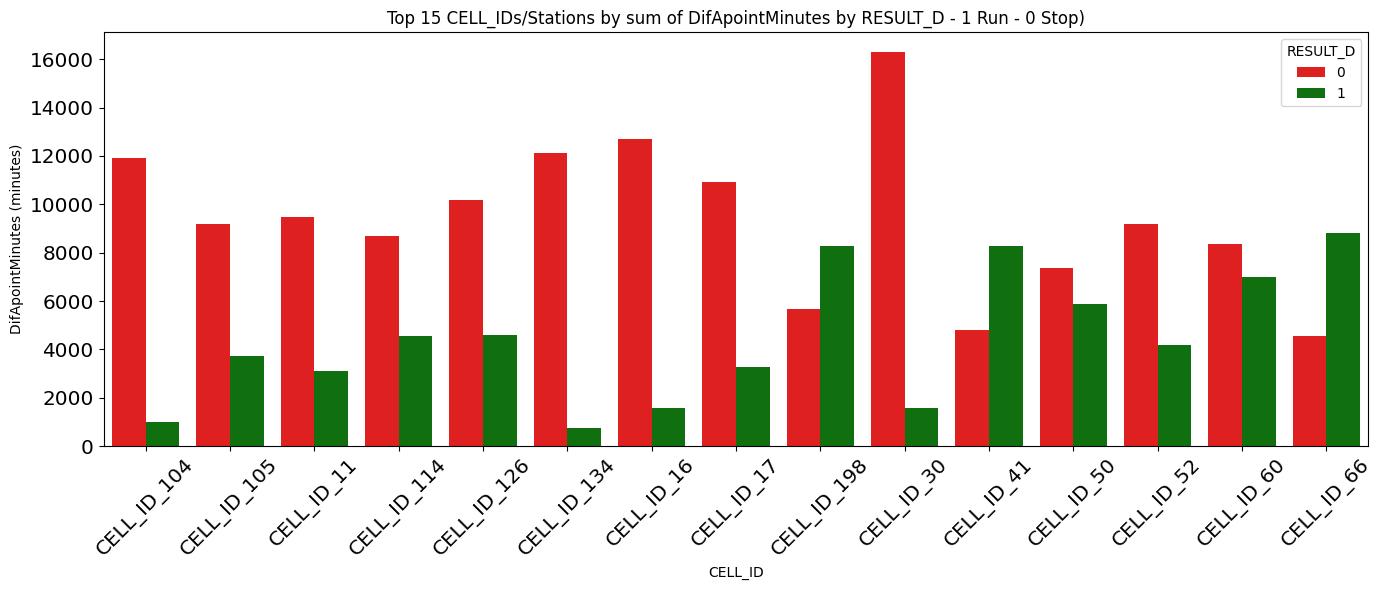

In [49]:
# Group by CELL_ID and RESULT_D, summing DifApointMinutes
df_grouped = df_final.groupby(['CELL_ID', 'RESULT_D'])['DifApointMinutes'].sum().reset_index()

custom_palette = {0: 'red', 1: 'green'}


# Sum total per CELL_ID (regardless of RESULT_D) to identify top 15
top_15_cells = (
    df_grouped.groupby('CELL_ID')['DifApointMinutes']
    .sum()
    .nlargest(15)
    .index
)

# Filter only the 15 CELL_IDs with largest totals
df_top15 = df_grouped[df_grouped['CELL_ID'].isin(top_15_cells)]

# Plot bar chart
plt.figure(figsize=(14, 6))
sns.barplot(data=df_top15, x='CELL_ID', y='DifApointMinutes', hue='RESULT_D',  palette=custom_palette)

# Customize
plt.title('Top 15 CELL_IDs/Stations by sum of DifApointMinutes by RESULT_D - 1 Run - 0 Stop)')
plt.xlabel('CELL_ID')
plt.ylabel('DifApointMinutes (minutes)')
plt.xticks(rotation=45)
plt.legend(title='RESULT_D')
plt.tight_layout()

# Show
plt.show()



In [50]:
# Basic statistics
mean_val = df_downtime_eda['DifApointMinutes'].mean()
median = df_downtime_eda['DifApointMinutes'].median()
mode = df_downtime_eda['DifApointMinutes'].mode()

# Quartiles
quartiles = df_downtime_eda['DifApointMinutes'].quantile([0.25, 0.5, 0.75, 1])

# Custom percentiles (example: 10%, 90%)
percentiles = df_downtime_eda['DifApointMinutes'].quantile([0.1, 0.5, 1])

# Display results
print(f"Mean Downtime : {mean_val}")
print(f"Median Downtime: {median}")
print(f"Mode Downtime: {mode.tolist()}")
print("Downtime Quartiles:")
print(quartiles)
print("Percentiles (10% , 50% and 100%):")
print(percentiles)


Mean Downtime : 97.08559498956159
Median Downtime: 31.0
Mode Downtime: [1.0]
Downtime Quartiles:
0.25       6.0
0.50      31.0
0.75      84.0
1.00    1433.0
Name: DifApointMinutes, dtype: float64
Percentiles (10% , 50% and 100%):
0.1       1.0
0.5      31.0
1.0    1433.0
Name: DifApointMinutes, dtype: float64


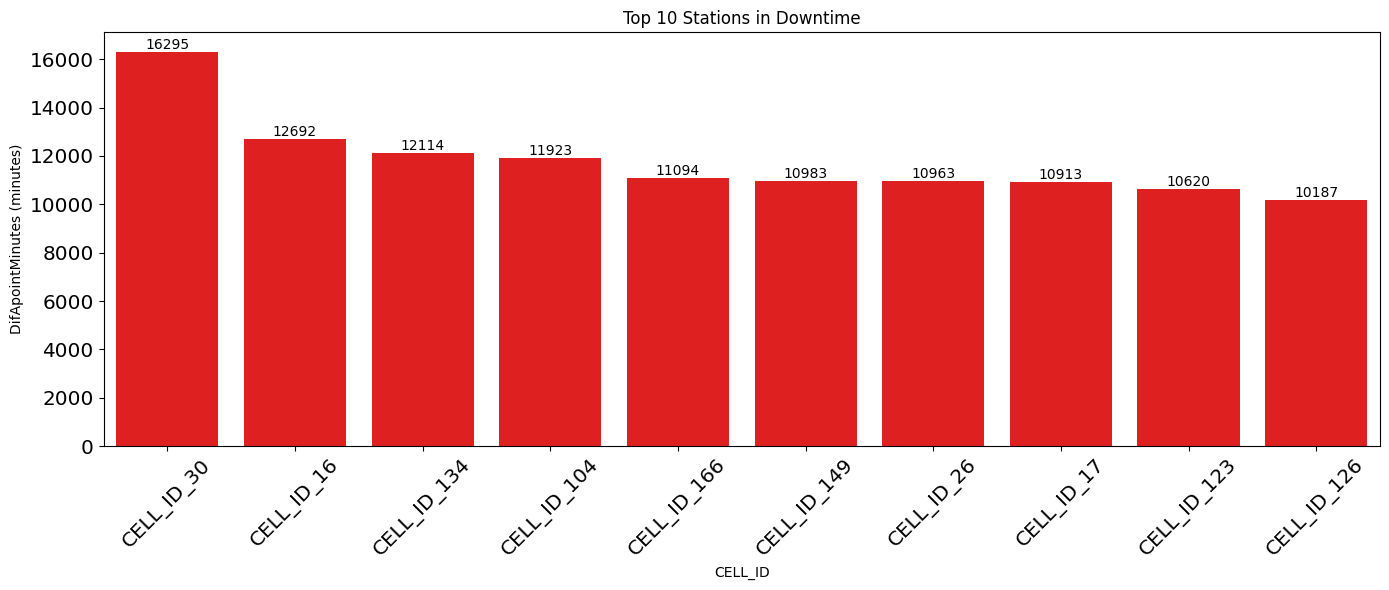

In [51]:
# Group by CELL_ID and RESULT_D, summing DifApointMinutes
df_grouped = df_final.groupby(['CELL_ID', 'RESULT_D'])['DifApointMinutes'].sum().reset_index()

# Filter only RESULT_D = 0 (downtime)
df_downtime = df_grouped[df_grouped['RESULT_D'] == 0]

# Select the 10 CELL_IDs with the largest sum of DifApointMinutes in downtime
top_10_downtime = df_downtime.nlargest(10, 'DifApointMinutes')

# Plot bar chart
plt.figure(figsize=(14, 6))
ax = sns.barplot(data=top_10_downtime, x='CELL_ID', y='DifApointMinutes', color='red')

# Add values on top of each bar
for p in ax.patches:
    altura = p.get_height()
    ax.annotate(f'{altura:.0f}',  # no decimals
                (p.get_x() + p.get_width() / 2., altura),
                ha='center', va='bottom',
                fontsize=10, color='black')

# Customize
plt.title('Top 10 Stations in Downtime')
plt.xlabel('CELL_ID')
plt.ylabel('DifApointMinutes (minutes)')
plt.xticks(rotation=45)
plt.tight_layout()

# Show
plt.show()



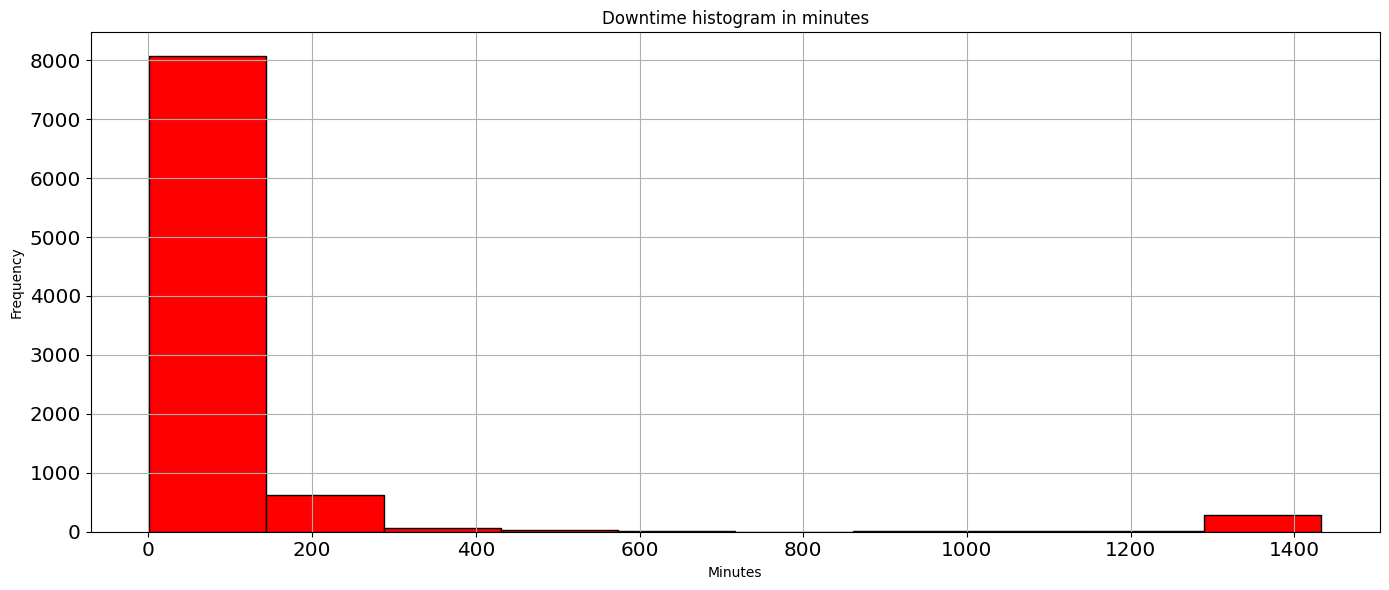

In [52]:
# Plot histogram
plt.figure(figsize=(14, 6))
plt.hist(df_downtime_eda['DifApointMinutes'], bins=10, color='red', edgecolor='black')
plt.title('Downtime histogram in minutes')
plt.xlabel('Minutes')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()


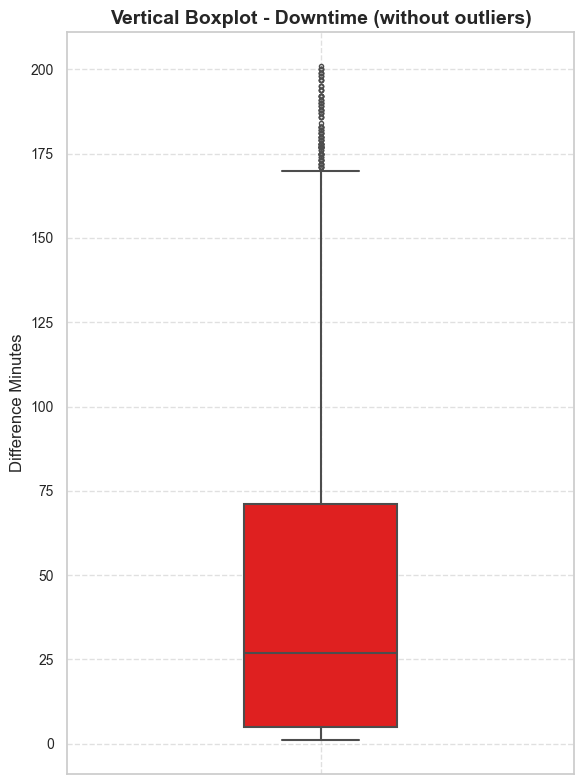

In [53]:
# Plot boxplot without outliers
# Calculate Q1, Q3 and IQR
Q1 = df_downtime_eda['DifApointMinutes'].quantile(0.25)
Q3 = df_downtime_eda['DifApointMinutes'].quantile(0.75)
IQR = Q3 - Q1

# Define limits
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

# Filter data without outliers
df_filtered = df_downtime_eda[
    (df_downtime_eda['DifApointMinutes'] >= lower_limit) &
    (df_downtime_eda['DifApointMinutes'] <= upper_limit)
]

sns.set(style="whitegrid", palette="pastel")

# Create vertical boxplot
plt.figure(figsize=(6, 8))
sns.boxplot(
    y='DifApointMinutes',
    data=df_filtered,
    color='red',
    width=0.3,
    fliersize=3,
    linewidth=1.5
)

plt.title('Vertical Boxplot - Downtime (without outliers)', fontsize=14, weight='bold')
plt.ylabel('Difference Minutes', fontsize=12)
plt.yticks(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()



In [54]:
# Basic statistics for production (running)
mean_prod = df_run_eda['DifApointMinutes'].mean()
median_prod = df_run_eda['DifApointMinutes'].median()
mode_prod = df_run_eda['DifApointMinutes'].mode()

# Quartiles
quartiles = df_run_eda['DifApointMinutes'].quantile([0.25, 0.5, 0.75, 1])

# Custom percentiles (example: 10%, 90%)
percentiles = df_run_eda['DifApointMinutes'].quantile([0.1, 0.5, 1])

# Display results
print(f"Mean Production : {mean_prod}")
print(f"Median Production: {median_prod}")
print(f"Mode Production: {mode_prod.tolist()}")
print("Production Quartiles:")
print(quartiles)
print("Percentiles (10% , 50% and 100%):")
print(percentiles)

Mean Production : 43.100385273972606
Median Production: 11.0
Mode Production: [10.0]
Production Quartiles:
0.25       5.0
0.50      11.0
0.75      22.0
1.00    1437.0
Name: DifApointMinutes, dtype: float64
Percentiles (10% , 50% and 100%):
0.1       2.3
0.5      11.0
1.0    1437.0
Name: DifApointMinutes, dtype: float64


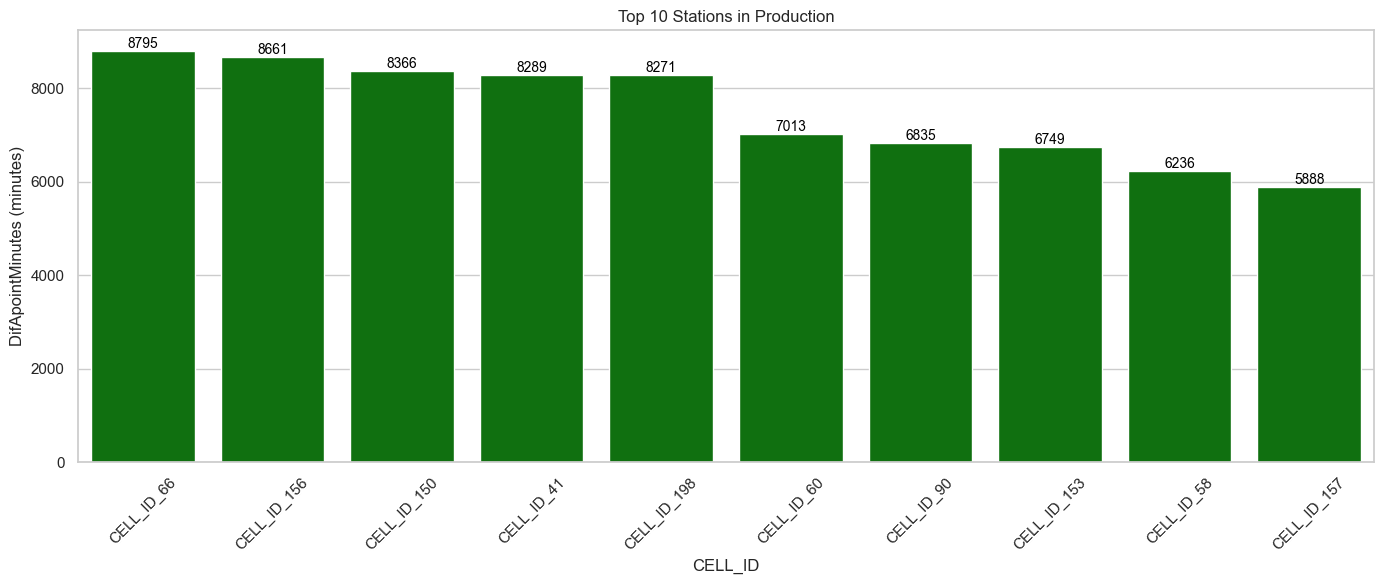

In [55]:
# Group by CELL_ID and RESULT_D, summing DifApointMinutes
df_grouped = df_final.groupby(['CELL_ID', 'RESULT_D'])['DifApointMinutes'].sum().reset_index()

# Filter only RESULT_D = 1 (running)
df_downtime = df_grouped[df_grouped['RESULT_D'] == 1]

# Select the 10 CELL_IDs with largest sum of DifApointMinutes in production
top_10_downtime = df_downtime.nlargest(10, 'DifApointMinutes')

# Plot bar chart
plt.figure(figsize=(14, 6))
ax = sns.barplot(data=top_10_downtime, x='CELL_ID', y='DifApointMinutes', color='green')

# Add values on top of each bar
for p in ax.patches:
    altura = p.get_height()
    ax.annotate(f'{altura:.0f}',  # no decimals
                (p.get_x() + p.get_width() / 2., altura),
                ha='center', va='bottom',
                fontsize=10, color='black')

# Customize
plt.title('Top 10 Stations in Production')
plt.xlabel('CELL_ID')
plt.ylabel('DifApointMinutes (minutes)')
plt.xticks(rotation=45)
plt.tight_layout()

# Show
plt.show()



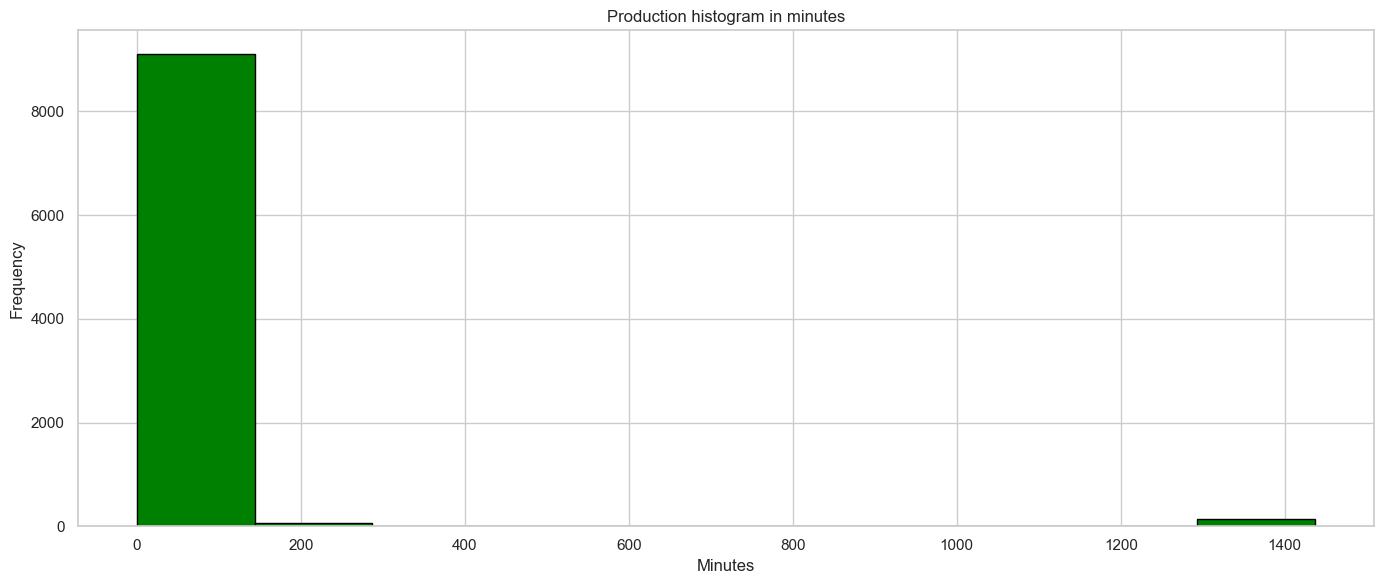

In [56]:
# Plot histogram for production minutes
plt.figure(figsize=(14, 6))
plt.hist(df_run_eda['DifApointMinutes'], bins=10, color='green', edgecolor='black')
plt.title('Production histogram in minutes')
plt.xlabel('Minutes')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()

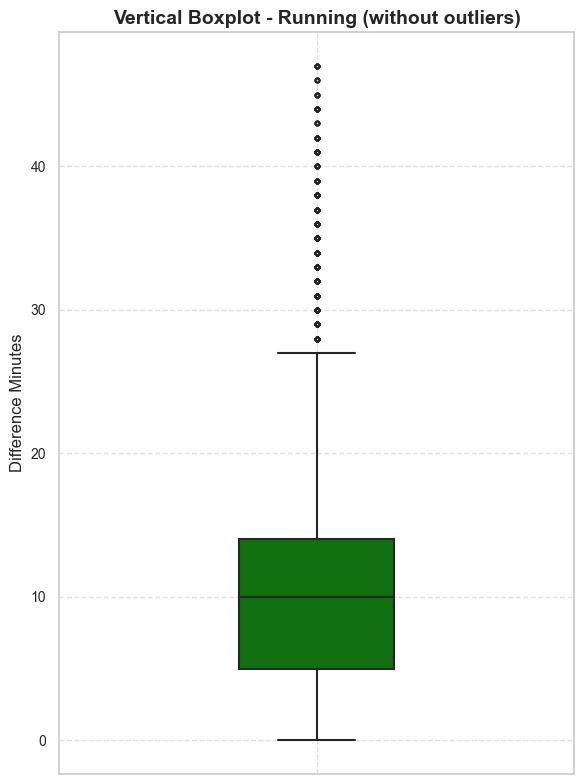

In [57]:
# Boxplot for production without outliers
Q1 = df_run_eda['DifApointMinutes'].quantile(0.25)
Q3 = df_run_eda['DifApointMinutes'].quantile(0.75)
IQR = Q3 - Q1

# Define limits
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

# Filter data without outliers
df_filtered = df_run_eda[
    (df_run_eda['DifApointMinutes'] >= lower_limit) &
    (df_run_eda['DifApointMinutes'] <= upper_limit)
]

sns.set(style="whitegrid", palette="pastel")

# Create vertical boxplot
plt.figure(figsize=(6, 8))
sns.boxplot(
    y='DifApointMinutes',
    data=df_filtered,
    color='green',
    width=0.3,
    fliersize=3,
    linewidth=1.5
)

plt.title('Vertical Boxplot - Running (without outliers)', fontsize=14, weight='bold')
plt.ylabel('Difference Minutes', fontsize=12)
plt.yticks(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()



In [58]:
print(df_final['DifApointMinutes'].sum())

1286306.0


In [59]:
print("## Total Time without Stops: Sum of machine running times. ")
vl_RunOKMin = df_final[df_final['RESULT_D'] == 1 ]['DifApointMinutes'].sum()
print(vl_RunOKMin,"Minutes")
print(vl_RunOKMin/3600," Hours")


## Total Time without Stops: Sum of machine running times. 
402730.0 Minutes
111.86944444444444  Hours


In [60]:
print("Total Stop Time: Sum of machine stop durations")
v_Tot_DownTime_Min = df_final[df_final['RESULT_D'] == 0 ]['DifApointMinutes'].sum()
print(v_Tot_DownTime_Min,"Minutes")
print(v_Tot_DownTime_Min/3600," Hours")


Total Stop Time: Sum of machine stop durations
883576.0 Minutes
245.43777777777777  Hours


In [61]:
# Totals
total_production = df_final.loc[df_final['RESULT_D'] == 1, 'DifApointMinutes'].sum()
total_downtime = df_final.loc[df_final['RESULT_D'] == 0, 'DifApointMinutes'].sum()
total_overall    = total_production + total_downtime

# Means
mean_production = df_final.loc[df_final['RESULT_D'] == 1, 'DifApointMinutes'].mean()
mean_downtime = df_final.loc[df_final['RESULT_D'] == 0, 'DifApointMinutes'].mean()

# Display results
print(f"Total Machine Time in Production: {total_production:.2f} minutes")
print(f"Total Machine Time in Downtime/Stop: {total_downtime:.2f} minutes")
print(f"Average Time in Production: {mean_production:.2f} minutes")
print(f"Average Time in Downtime/Stop: {mean_downtime:.2f} minutes")

# Total failures
failure_count = df_final[df_final['RESULT_D'] == 0].shape[0]
print(f'Total failures : {failure_count}')

# Downtime percentage
perc_downtime  = (total_downtime / total_overall) * 100
print(f"Percent Time in Downtime/Stop: {perc_downtime:.2f} %")

# Production percentage
perc_production  = (total_production / total_overall) * 100
print(f"Percent Time in Production : {perc_production:.2f} %")

 

Total Machine Time in Production: 402730.00 minutes
Total Machine Time in Downtime/Stop: 883576.00 minutes
Average Time in Production: 43.10 minutes
Average Time in Downtime/Stop: 97.09 minutes
Total failures : 9101
Percent Time in Downtime/Stop: 68.69 %
Percent Time in Production : 31.31 %


MTBF (Mean Time Between Failures): Average time a machine operates before failing.



In [62]:
v_mtbf = (  total_production  +  total_downtime ) / failure_count
print(v_mtbf, "Global MTBF (Mean Time Between Failures): Average minutes a machine operates before failing")

141.33677617844194 Global MTBF (Mean Time Between Failures): Average minutes a machine operates before failing


In [63]:
# % Machine Availability: Percentage of time machines were operational.



- Planned total time: time the machine should be available (e.g., 3 shifts of 8h = 1,440 minutes).
- Stop time (downtime): sum of periods when the machine was inoperative due to failures, maintenance, etc.


MTTR (Global Mean Time To Repair): Average minutes required to repair a global failure.

In [64]:

v_mttr =  total_downtime  / failure_count
print(v_mttr, "MTTR (Global Mean Time To Repair): Average minutes required to repair a global failure.")


97.08559498956159 MTTR (Global Mean Time To Repair): Average minutes required to repair a global failure.


In [65]:
mapping = {
    113: "Emergency Breakdown",
    9: "Mechanical Failure",
    14: "Electrical Issue",
    10: "Maintenance Overrun",
    35: "Operator Error",
    46: "Material Shortage",
    122: "Setup Time Overrun",
    9004: "Oil/Coolant Leak",
    143: "Planned Maintenance",
    0: "Run Production"
}

# 2. Create a new column based on mapping
df_final['Description_Code'] = df_final['Reason_Code'].map(mapping)

In [66]:
df_final.head(5)

,CELL_ID,Part_Number,Reported_Pointed,Local,Date,Start_Time_Appoint,End_TimeAppoint,Shift,Station,ReasonforStop,stop/prodution,Reason_Code,PARM12,PARM13,PARM15,FLAG,SENT,RESULT,TIME_STAMP,ID,Date_D,Time_D,WeekDay,Month_D,RESULT_D,Tot_DownTime,Tot_Run_OK,DifApointMinutes,Description_Code
0,CELL_ID_195,PART_292,REPORTER_10,111,2025-01-10,1900-01-01 22:54:00,1900-01-01 23:02:00,3,STATION_173,10,9,10.0,0.0,0,2110.0,REP,1,OK,2025-01-10 23:32:37.650,97D6D7B9-3ED2-49F4-B0D4-87B5834304D2,2025-01-10,23:32:37,Friday,January,1,0,0 days 00:08:00,8.0,Maintenance Overrun
1,CELL_ID_129,PART_36,REPORTER_511,111,2025-01-19,1900-01-01 13:32:00,1900-01-01 13:38:00,2,STATION_130,10,9,14.0,0.0,250192,2110.0,REP,1,OK,2025-01-19 14:32:22.770,D9840CC0-A909-4B04-97F3-5ED65210CE52,2025-01-19,14:32:22,Sunday,January,1,0,0 days 00:06:00,6.0,Electrical Issue
2,CELL_ID_106,PART_578,REPORTER_405,111,2025-01-28,1900-01-01 20:31:00,1900-01-01 20:35:00,3,STATION_95,10,9,122.0,0.0,202575,2110.0,REP,1,OK,2025-01-28 21:32:54.643,FE102354-38A3-4140-AAB5-D7D5F3AEC699,2025-01-28,21:32:54,Tuesday,January,1,0,0 days 00:04:00,4.0,Setup Time Overrun
3,CELL_ID_83,PART_230,REPORTER_133,111,2025-01-16,1900-01-01 18:01:00,1900-01-01 18:36:00,3,STATION_152,10,4,0.0,2.0,250163,2.6,REP,1,||runLabor#1(emp-1000367) item#1(part-40117524...,2025-01-16 19:06:44.560,DB8B4DD3-7E6D-4A92-A3C7-29ED51AA283B,2025-01-16,19:06:44,Thursday,January,0,0 days 00:35:00,0,35.0,Run Production
4,CELL_ID_182,PART_462,REPORTER_365,111,2025-01-24,1900-01-01 14:48:00,1900-01-01 17:40:00,3,STATION_194,10,4,0.0,1.0,250243,2.6,REP,1,||runLabor#1(emp-1001540) item#1(part-40128540...,2025-01-24 18:06:45.070,B1FED063-D65A-4835-BCDA-7C48D26DFFA9,2025-01-24,18:06:45,Friday,January,0,0 days 02:52:00,0,172.0,Run Production


In [67]:


# Save locally
df_final.to_csv('dataset/final_downtime_10perc.csv', index=False)

In [68]:
df_final.size

534905

In [69]:
df_final_downtime_screabled = df_final


In [70]:
## Function to scramble values while keeping frequency
def anonymize_column(df, column_name, prefix):
    unique_values = df[column_name].unique()
    # Generate unique fake labels
    fake_labels = [f"{prefix}_{i+1}" for i in range(len(unique_values))]
    np.random.shuffle(fake_labels)
    # Create mapping
    mapping = dict(zip(unique_values, fake_labels))
    # Apply mapping
    df[column_name] = df[column_name].map(mapping)
    return mapping

# Copy the original dataset
#df_scrambled = df_final_downtime_screabled.copy()

# Apply anonymization to desired columns
#cell_id_map = anonymize_column(df_scrambled, 'CELL_ID', 'CELL')
#part_number_map = anonymize_column(df_scrambled, 'Part_Number', 'PART')
#station_map = anonymize_column(df_scrambled, 'Station', 'STATION')

# Check that original values have been replaced
#print("Unique values after scrambling:")
#print("CELL_ID:", df_scrambled['CELL_ID'].unique()[:5])
#print("Part_Number:", df_scrambled['Part_Number'].unique()[:5])
#print("Station:", df_scrambled['Station'].unique()[:5])

df_scrambled = df_final_downtime_screabled.copy()

In [71]:
df_scrambled.head(5)

,CELL_ID,Part_Number,Reported_Pointed,Local,Date,Start_Time_Appoint,End_TimeAppoint,Shift,Station,ReasonforStop,stop/prodution,Reason_Code,PARM12,PARM13,PARM15,FLAG,SENT,RESULT,TIME_STAMP,ID,Date_D,Time_D,WeekDay,Month_D,RESULT_D,Tot_DownTime,Tot_Run_OK,DifApointMinutes,Description_Code
0,CELL_ID_195,PART_292,REPORTER_10,111,2025-01-10,1900-01-01 22:54:00,1900-01-01 23:02:00,3,STATION_173,10,9,10.0,0.0,0,2110.0,REP,1,OK,2025-01-10 23:32:37.650,97D6D7B9-3ED2-49F4-B0D4-87B5834304D2,2025-01-10,23:32:37,Friday,January,1,0,0 days 00:08:00,8.0,Maintenance Overrun
1,CELL_ID_129,PART_36,REPORTER_511,111,2025-01-19,1900-01-01 13:32:00,1900-01-01 13:38:00,2,STATION_130,10,9,14.0,0.0,250192,2110.0,REP,1,OK,2025-01-19 14:32:22.770,D9840CC0-A909-4B04-97F3-5ED65210CE52,2025-01-19,14:32:22,Sunday,January,1,0,0 days 00:06:00,6.0,Electrical Issue
2,CELL_ID_106,PART_578,REPORTER_405,111,2025-01-28,1900-01-01 20:31:00,1900-01-01 20:35:00,3,STATION_95,10,9,122.0,0.0,202575,2110.0,REP,1,OK,2025-01-28 21:32:54.643,FE102354-38A3-4140-AAB5-D7D5F3AEC699,2025-01-28,21:32:54,Tuesday,January,1,0,0 days 00:04:00,4.0,Setup Time Overrun
3,CELL_ID_83,PART_230,REPORTER_133,111,2025-01-16,1900-01-01 18:01:00,1900-01-01 18:36:00,3,STATION_152,10,4,0.0,2.0,250163,2.6,REP,1,||runLabor#1(emp-1000367) item#1(part-40117524...,2025-01-16 19:06:44.560,DB8B4DD3-7E6D-4A92-A3C7-29ED51AA283B,2025-01-16,19:06:44,Thursday,January,0,0 days 00:35:00,0,35.0,Run Production
4,CELL_ID_182,PART_462,REPORTER_365,111,2025-01-24,1900-01-01 14:48:00,1900-01-01 17:40:00,3,STATION_194,10,4,0.0,1.0,250243,2.6,REP,1,||runLabor#1(emp-1001540) item#1(part-40128540...,2025-01-24 18:06:45.070,B1FED063-D65A-4835-BCDA-7C48D26DFFA9,2025-01-24,18:06:45,Friday,January,0,0 days 02:52:00,0,172.0,Run Production


In [72]:
# Save locally
df_scrambled.to_csv('dataset/final_DowntimeScrambled_v2.csv', index=False)

# SAP SAC Donwtime DashBoard and ROI Analisys


Storytelling – Reduce Downtime Operations
Business Issue Today
An industrial customer is facing a significant production efficiency challenge. Machines spend
the majority of available time in stopped or degraded states, resulting in lost output, increased
costs, and reduced service levels.
The dashboard below represents the real operational behavior of the production environment. All
KPIs and visual elements are preserved exactly as measured.
The dashboard is a Solution Proposal and it represents the real operational behavior of the
production environment. All KPIs and visual elements are preserved exactly as measured.
Get insights from data in Sac Models to gain productive.

### The dashboard Downtime Proposed Solution.

<img src="images/DashBoarc_SAC_jupter_01.jpg">

### The dashboard Downtime to get Insights from
Joule Proposed Solution.

<img src="images/DashBoarc_SAC_Joule_jupter_02.jpg">

<img src="images/DashBoarc_SAC_Architecture_jupter_03.jpg"/>

<img src="images/DashBoarc_SAC_Architecture_jupter_04.jpg"/>

<img src="images/DashBoarc_SAC_Rebility_jupter_05.jpg"/>

<img src="images/DashBoarc_SAC_KPI_jupter_06.jpg"/>

<img src="images/DashBoarc_SAC_BoardLevel_jupter_07.jpg"/>

<img src="images/DashBoarc_SAC_Executive_jupter_07.jpg"/>

<img src="images/DashBoarc_SAC_ROI_jupter_09.jpg"/>